# Air Pollution Prediction — NO2 AQI

**Yun-Chieh Chen**

## 1. Problem Definition & Research

### Why this matters
Air pollution is a major public health issue. Long-term exposure to pollutants like NO2, O3, SO2, and CO is linked to respiratory and cardiovascular disease. The EPA runs a network of air quality monitoring stations across the US, but coverage is limited — a lot of locations and time periods don't have direct measurements. If we can predict pollutant levels (like NO2) from the pollutants we *do* have data on, plus basic location info, that could help fill in gaps in monitoring coverage and support public health decisions (e.g., issuing air quality alerts in areas without a nearby sensor).

I also have a personal reason for this topic: I studied Geography (GIS) in undergrad, so I'm interested in whether *location* itself is a useful predictor here, not just something to visualize on a map. This connects to an idea from environmental geography called Land Use Regression (LUR), where pollution is predicted using spatial/location features instead of just weather or chemistry.

### Related work
LUR-style models are a well-established approach in environmental science for estimating pollution at locations without direct monitoring — they typically combine geographic features (traffic density, land use, proximity to industrial areas) with whatever monitoring data is available. This project is a simplified version of that idea: instead of detailed land-use data, I'm testing whether just knowing the *state* a station is in adds predictive value.

### Dataset
- **Source:** [U.S. Pollution Data (2000–2016)](https://www.kaggle.com/datasets/sogun3/uspollution), Kaggle, originally compiled from the EPA's Air Quality System.
- **Original size:** ~1.75 million rows, 29 columns, covering all 50 states from 2000–2016.
- **Cleaning:** The raw data was too large and had duplicate rows per station per day (same site/date split across different measurement hours). I filtered to 4 states (California, Texas, New York, Arizona) and 2010–2015, then grouped by station + date and averaged the numeric columns to get one row per station per day. This left **73,516 rows**.
- **Key features:** `O3 AQI`, `SO2 AQI`, `CO AQI` (other pollutant readings), and `State` (location). 
- **Target variable:** `NO2 AQI` — a continuous number, so this is a **regression** problem.

### The specific question I'm testing
Can I predict NO2 AQI using the other pollutant readings? And more specifically: does adding location (state) actually improve the prediction, or is it just noise?

## 2. Load and Clean the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv('pollution_clean.csv')
df['Date Local'] = pd.to_datetime(df['Date Local'])  # need real dates for the time-based split later
print(df.shape)
df.head()

(73556, 20)


,State Code,County Code,Site Num,Address,State,County,City,Date Local,NO2 Mean,NO2 1st Max Value,NO2 AQI,O3 Mean,O3 1st Max Value,O3 AQI,SO2 Mean,SO2 1st Max Value,SO2 AQI,CO Mean,CO 1st Max Value,CO AQI
0,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2010-01-01,32.208333,48.0,45.0,0.013208,0.034,29.0,3.310417,5.30,9.0,1.005592,1.80,18.0
1,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2010-01-02,35.500000,51.0,48.0,0.010000,0.025,21.0,4.066667,6.65,10.0,0.966666,1.70,15.0
2,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2010-01-03,33.166667,55.0,52.0,0.011042,0.028,24.0,3.191667,5.00,9.0,0.872916,1.65,16.0
3,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2010-01-04,35.625000,55.0,52.0,0.013875,0.036,31.0,3.777083,8.15,13.0,0.860417,1.75,15.0
4,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2010-01-05,42.708333,60.0,57.0,0.011292,0.030,25.0,5.033334,8.65,13.0,0.966666,1.70,15.0


In [2]:
print(df.isnull().sum())

State Code            0
County Code           0
Site Num              0
Address               0
State                 0
County                0
City                  0
Date Local            0
NO2 Mean              0
NO2 1st Max Value     0
NO2 AQI               0
O3 Mean               0
O3 1st Max Value      0
O3 AQI                0
SO2 Mean              0
SO2 1st Max Value     0
SO2 AQI               0
CO Mean               0
CO 1st Max Value      0
CO AQI               40
dtype: int64


In [3]:
# drop NA(CO AQI around 40 NA)
df = df.dropna(subset=['CO AQI']).copy()

# sort by date
df = df.sort_values('Date Local').reset_index(drop=True)

print(df.shape)
print(df['Date Local'].min(), 'to', df['Date Local'].max())

(73516, 20)
2010-01-01 00:00:00 to 2015-12-31 00:00:00


## 2. Data Exploration & Visualization

Before building any model, I want to check how these pollutants relate to NO2, since that tells me whether they're actually reasonable features to use. O3, SO2, and CO are all included because they're pollutants commonly released alongside NO2 from the same sources (vehicle traffic, industrial combustion), so it's reasonable to expect some relationship. `State` is included to directly test the location question from Section 1.

In [4]:
df[['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']].describe()

,NO2 AQI,O3 AQI,SO2 AQI,CO AQI
count,73516.000000,73516.000000,73516.000000,73516.000000
mean,21.334709,36.452840,2.166331,5.035798
std,14.603648,19.308356,4.461222,4.342402
min,0.000000,0.000000,0.000000,0.000000
25%,8.000000,26.000000,0.000000,2.000000
50%,20.000000,33.000000,1.000000,3.000000
75%,32.000000,42.000000,3.000000,7.000000
max,111.000000,218.000000,147.000000,67.000000


In [5]:
df[['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']].corr()['NO2 AQI'].sort_values(ascending=False)

NO2 AQI    1.000000
CO AQI     0.633594
SO2 AQI    0.266060
O3 AQI     0.073389
Name: NO2 AQI, dtype: float64

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
corr_matrix = df[['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Between Pollutants', fontweight='bold')
plt.tight_layout()
plt.show()

A heatmap makes it easier to see all the correlations at once instead of just reading down a list. CO AQI clearly stands out as the strongest correlate with NO2 AQI (0.63), which makes sense since both mostly come from vehicle traffic and combustion. O3 AQI is barely correlated (0.07) — this actually lines up with atmospheric chemistry, since NO2 gets consumed in reactions that produce O3, so they don't necessarily rise and fall together.

In [6]:
df.groupby('State')['NO2 AQI'].agg(['mean', 'std', 'count']).round(2)

,mean,std,count
State,,,
Arizona,30.92,12.64,6148
California,19.83,14.67,48086
New York,26.68,14.62,5267
Texas,20.30,13.04,14015


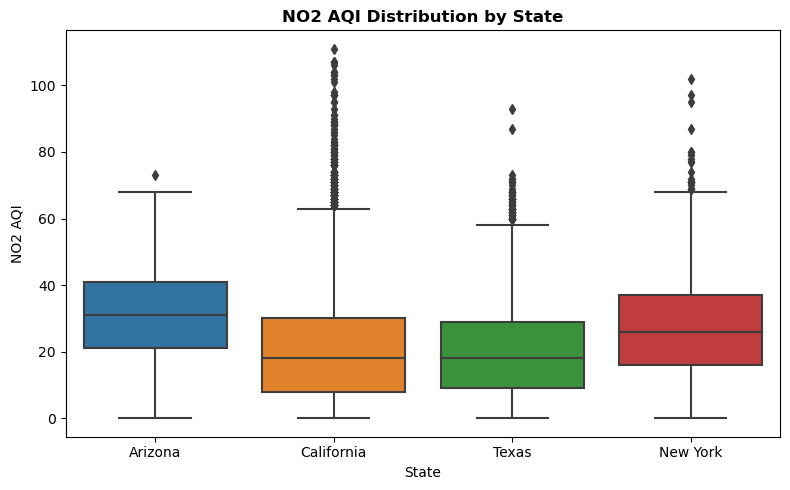

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='State', y='NO2 AQI', ax=ax)
ax.set_title('NO2 AQI Distribution by State', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('NO2 AQI')
plt.tight_layout()
plt.show()

In [8]:
# splitting by time instead of randomly, since this is daily data --
# a random split would let the model 'see' days right next to test days during training
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]  # earliest 80% of dates
test = df.iloc[split_point:]   # most recent 20% of dates

print('Train date range:', train['Date Local'].min(), 'to', train['Date Local'].max())
print('Test date range:', test['Date Local'].min(), 'to', test['Date Local'].max())
print('Train size:', len(train), 'Test size:', len(test))

Train date range: 2010-01-01 00:00:00 to 2014-09-16 00:00:00
Test date range: 2014-09-16 00:00:00 to 2015-12-31 00:00:00
Train size: 58812 Test size: 14704


In [9]:
# one-hot encoding State (not City) to avoid ending up with dozens of columns
train_encoded = pd.get_dummies(train, columns=['State'], drop_first=True)
test_encoded = pd.get_dummies(test, columns=['State'], drop_first=True)

# align in case a state ends up missing from train or test after the split
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

state_cols = [c for c in train_encoded.columns if c.startswith('State_')]
print('State dummy columns:', state_cols)

State dummy columns: ['State_California', 'State_New York', 'State_Texas']


In [10]:
target = 'NO2 AQI'
pollutant_features = ['O3 AQI', 'SO2 AQI', 'CO AQI']

X_train_no_geo = train_encoded[pollutant_features]
X_test_no_geo = test_encoded[pollutant_features]
y_train = train_encoded[target]
y_test = test_encoded[target]

model_no_geo = LinearRegression()
model_no_geo.fit(X_train_no_geo, y_train)
pred_no_geo = model_no_geo.predict(X_test_no_geo)

r2_no_geo = r2_score(y_test, pred_no_geo)
rmse_no_geo = np.sqrt(mean_squared_error(y_test, pred_no_geo))
mae_no_geo = mean_absolute_error(y_test, pred_no_geo)

print('=== Model A: WITHOUT geography ===')
print(f'R²:   {r2_no_geo:.4f}')
print(f'RMSE: {rmse_no_geo:.4f}')
print(f'MAE:  {mae_no_geo:.4f}')

=== Model A: WITHOUT geography ===
R²:   0.4081
RMSE: 10.8951
MAE:  8.6483


In [11]:
# same features as Model A, plus the state dummy columns -- this is the direct
# comparison to see if location actually helps
X_train_geo = train_encoded[pollutant_features + state_cols]
X_test_geo = test_encoded[pollutant_features + state_cols]

model_geo = LinearRegression()
model_geo.fit(X_train_geo, y_train)
pred_geo = model_geo.predict(X_test_geo)

r2_geo = r2_score(y_test, pred_geo)
rmse_geo = np.sqrt(mean_squared_error(y_test, pred_geo))
mae_geo = mean_absolute_error(y_test, pred_geo)

print('=== Model B: WITH geography (State) ===')
print(f'R²:   {r2_geo:.4f}')
print(f'RMSE: {rmse_geo:.4f}')
print(f'MAE:  {mae_geo:.4f}')

print(f'\nR² improvement from adding geography: {r2_geo - r2_no_geo:.4f}')

=== Model B: WITH geography (State) ===
R²:   0.4621
RMSE: 10.3859
MAE:  8.2102

R² improvement from adding geography: 0.0540


In [12]:
# same features as Model B, different algorithm -- testing whether a model that can
# capture non-linear relationships does better than plain linear regression
# max_depth=10 caps how complex each tree can get, to avoid overfitting
model_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model_rf.fit(X_train_geo, y_train)
pred_rf = model_rf.predict(X_test_geo)

r2_rf = r2_score(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
mae_rf = mean_absolute_error(y_test, pred_rf)

print('=== Model C: Random Forest (with geography) ===')
print(f'R²:   {r2_rf:.4f}')
print(f'RMSE: {rmse_rf:.4f}')
print(f'MAE:  {mae_rf:.4f}')

=== Model C: Random Forest (with geography) ===
R²:   0.5501
RMSE: 9.4991
MAE:  7.4322


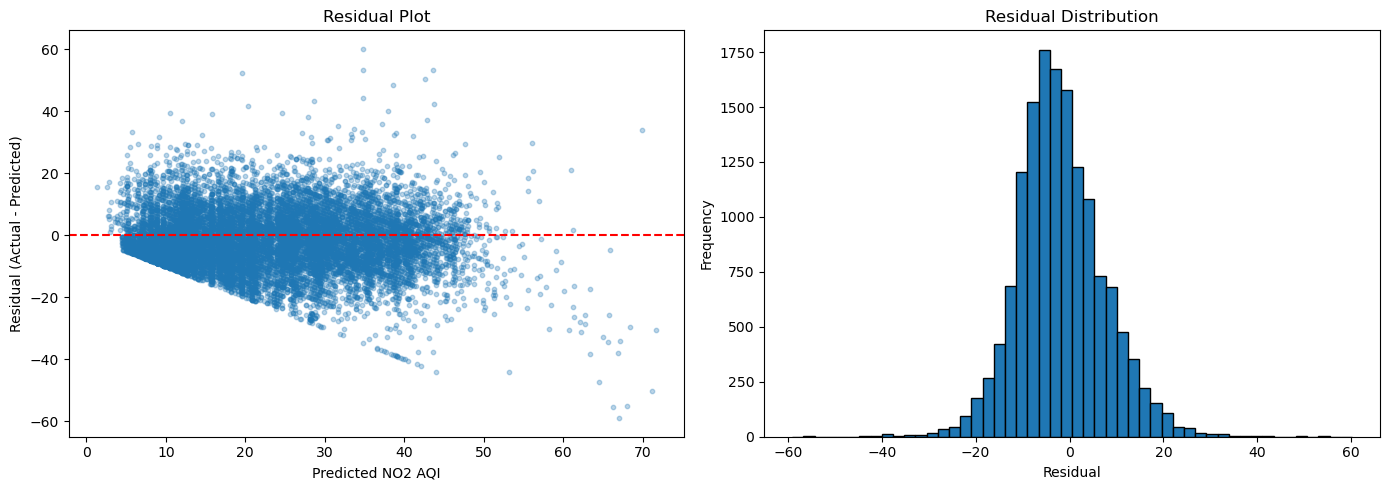

Residual mean: -1.9566348261895634
Residual std: 9.29575213980292


In [13]:
residuals = y_test - pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_rf, residuals, alpha=0.3, s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted NO2 AQI')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print('Residual mean:', residuals.mean())
print('Residual std:', residuals.std())

**Discussion:** Random Forest got a decent R² bump (0.55), but the residual plot shows a problem — the errors get bigger as the predicted NO2 AQI goes up, and the model tends to underestimate NO2 on the highest-pollution days. So the model does okay on typical/low pollution days but isn't very reliable exactly when it matters most (e.g., if you wanted to use this to issue high-pollution alerts).

In [14]:
importance = pd.DataFrame({
    'Feature': X_train_geo.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

            Feature  Importance
2            CO AQI    0.751579
3  State_California    0.102109
0            O3 AQI    0.081840
1           SO2 AQI    0.055219
4    State_New York    0.005751
5       State_Texas    0.003502


**Discussion:** Looking at feature importance, the “geography helps” effect isn't spread evenly across states — it's almost entirely coming from California (10%+ importance), while New York and Texas barely register (under 1% combined). This probably isn't really a “state” effect so much as California having genuinely different air quality patterns (e.g., temperature inversion in the LA basin trapping pollutants). So the takeaway isn't “location always matters,” it's “this specific location matters a lot.”

In [ ]:
# quick visual summary of the three models tried, in order
model_names = ['Linear (no geo)', 'Linear (+ state)', 'Random Forest (+ state)']
r2_scores = [r2_no_geo, r2_geo, r2_rf]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(model_names, r2_scores, color=['#8899aa', '#4c78a8', '#2ca02c'])
ax.set_ylabel('R²')
ax.set_title('Model Comparison: R² Score', fontweight='bold')
ax.set_ylim(0, 0.65)
for bar, score in zip(bars, r2_scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.01, f'{score:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

This chart makes the model comparison easy to see at a glance: adding location gives a small boost, and switching to Random Forest gives a bigger one. Each bar represents a step in the experiment — first testing pollutants alone, then adding geography, then trying a more flexible algorithm.

## 5. Final Report

### Summary of results
My question at the start was: does adding location help predict NO2 AQI? The answer is yes, but not by a ton on its own.

| Model | R² | RMSE | MAE |
|---|---|---|---|
| Linear Regression (pollutants only) | 0.408 | 10.90 | 8.65 |
| Linear Regression (+ state) | 0.462 | 10.39 | 8.21 |
| Random Forest (+ state) | 0.550 | 9.50 | 7.43 |

Adding state to the linear regression brought R² from 0.408 to 0.462. Switching to Random Forest pushed it up more, to 0.550 — so the pollutants and NO2 don't just have a straight-line relationship, Random Forest is better at catching that.

Looking at feature importance, the location effect is basically all coming from California, not the other states. That matches the EDA — California had a lot more extreme high-pollution days than Texas, New York, or Arizona, most likely due to real atmospheric conditions like temperature inversion trapping pollutants in the LA basin, not just a generic "state" effect.

### What this means in practice (business/public health insight)
For someone trying to estimate air quality in a spot without a monitoring station, this suggests two things: (1) knowing the levels of other pollutants gets you a decent chunk of the way there, and (2) knowing *specifically* whether you're in a place with California-like conditions (dense urban area, prone to inversion, etc.) matters a lot more than just knowing the state name. A model like this could support a rough early-warning system for locations without sensors — flagging when nearby pollutant readings suggest NO2 is probably elevated — but it shouldn't be the only signal used, given the accuracy limits below.

### Limitations
- The residual plot showed the model is noticeably less accurate at high NO2 levels — exactly the days where accuracy matters most (e.g., for pollution alerts). Errors trend toward under-predicting the worst pollution days.
- R² of 0.55 means the model still leaves almost half the variation in NO2 unexplained. It's useful as a rough estimate, not a precise one.
- Only 4 states were used, and California makes up the majority of the data (about two-thirds), so the "geography" finding may not generalize well to states very different from these four.
- `State` is a fairly blunt way to represent location — it doesn't capture *why* California is different (traffic density, geography, weather patterns), just that it is.

### Future work
- Add more direct spatial features rather than just state name — e.g., distance to a major city, urban vs. rural classification, or elevation — to better capture *why* location matters, following the Land Use Regression idea mentioned in Section 1.
- Try weighting high-pollution observations more heavily during training, or treating "NO2 AQI above a threshold" as a separate classification problem, to specifically improve accuracy on the worst pollution days.
- Extend to more states to see whether the California effect holds up or whether other high-pollution regions show a similar pattern.

### What I did in this project
- Cleaned up a messy 1.75M-row EPA dataset into something usable (73,516 rows)
- Split the data by time instead of randomly, since it's daily data and random splitting would leak information between nearby days
- Directly tested whether location helps (with vs. without state) instead of just assuming it does
- Compared a linear model against Random Forest instead of only trying one algorithm
- Checked the residuals instead of just reporting R², and found a real limitation of the model